In [1]:
import torch
import numpy as np

print(f"PyTorch version : {torch.__version__}")
print(f"GPU disponible : {torch.cuda.is_available()}")
# Sur Mac M1/M2, on utilise MPS au lieu de CUDA
print(f"MPS disponible : {torch.backends.mps.is_available()}")

# Définir le device
device = torch.device("mps" if torch.backends.mps.is_available() 
                       else "cpu")
print(f"Device utilisé : {device}")

print("\n=== CRÉER DES TENSEURS ===")
# Depuis une liste
x = torch.tensor([1.0, 2.0, 3.0])
print(f"Tenseur 1D : {x}")
print(f"Shape : {x.shape}")
print(f"Dtype : {x.dtype}")

# Tenseurs spéciaux
zeros = torch.zeros(3, 4)
ones = torch.ones(2, 3)
aleatoire = torch.rand(3, 3)
normale = torch.randn(3, 3)
identite = torch.eye(3)

print(f"\nZeros shape : {zeros.shape}")
print(f"Ones :\n{ones}")
print(f"\nAléatoire :\n{aleatoire}")

# Depuis NumPy
np_array = np.array([1, 2, 3, 4])
tensor_from_np = torch.from_numpy(np_array)
print(f"\nDepuis NumPy : {tensor_from_np}")

# Vers NumPy
back_to_np = tensor_from_np.numpy()
print(f"Retour NumPy : {back_to_np}")

PyTorch version : 2.12.1
GPU disponible : False
MPS disponible : True
Device utilisé : mps

=== CRÉER DES TENSEURS ===
Tenseur 1D : tensor([1., 2., 3.])
Shape : torch.Size([3])
Dtype : torch.float32

Zeros shape : torch.Size([3, 4])
Ones :
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Aléatoire :
tensor([[0.1852, 0.9136, 0.7449],
        [0.6461, 0.3798, 0.8293],
        [0.1865, 0.7740, 0.5079]])

Depuis NumPy : tensor([1, 2, 3, 4])
Retour NumPy : [1 2 3 4]


In [2]:
# OPÉRATIONS SUR LES TENSEURS
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print("=== OPÉRATIONS ===")
print(f"a + b :\n{a + b}")
print(f"a * b :\n{a * b}")        # element-wise
print(f"a @ b :\n{a @ b}")        # multiplication matricielle
print(f"Transposée :\n{a.T}")
print(f"Somme : {a.sum()}")
print(f"Moyenne : {a.mean()}")
print(f"Max : {a.max()}")

print("\n=== RESHAPE ===")
x = torch.arange(12, dtype=torch.float32)
print(f"Original : {x}")
print(f"Reshape (3,4) :\n{x.reshape(3, 4)}")
print(f"Reshape (2,-1) :\n{x.reshape(2, -1)}")

print("\n=== AUTOGRAD (différentiation automatique) ===")
# requires_grad=True → PyTorch va calculer les gradients
x = torch.tensor([2.0], requires_grad=True)
y = x**3 + 2*x   # y = x³ + 2x

y.backward()     # calcule dy/dx
print(f"x = {x.item()}")
print(f"y = x³ + 2x = {y.item()}")
print(f"dy/dx = 3x² + 2 = {x.grad.item()}")   # 3(4) + 2 = 14
print(f"Valeur théorique : {3*(2**2) + 2}")

=== OPÉRATIONS ===
a + b :
tensor([[ 6.,  8.],
        [10., 12.]])
a * b :
tensor([[ 5., 12.],
        [21., 32.]])
a @ b :
tensor([[19., 22.],
        [43., 50.]])
Transposée :
tensor([[1., 3.],
        [2., 4.]])
Somme : 10.0
Moyenne : 2.5
Max : 4.0

=== RESHAPE ===
Original : tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])
Reshape (3,4) :
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
Reshape (2,-1) :
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.]])

=== AUTOGRAD (différentiation automatique) ===
x = 2.0
y = x³ + 2x = 12.0
dy/dx = 3x² + 2 = 14.0
Valeur théorique : 14


In [3]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# CONSTRUIRE UN RÉSEAU DE NEURONES
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Instancier le modèle
model = MLP(
    input_size=10,
    hidden_sizes=[64, 32],
    output_size=1
)

print("=== ARCHITECTURE ===")
print(model)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")

# Tester un forward pass
x_test = torch.randn(5, 10)   # 5 exemples, 10 features
output = model(x_test)
print(f"\nInput shape  : {x_test.shape}")
print(f"Output shape : {output.shape}")
print(f"Output :\n{output}")

=== ARCHITECTURE ===
MLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Nombre de paramètres : 2,817

Input shape  : torch.Size([5, 10])
Output shape : torch.Size([5, 1])
Output :
tensor([[0.3040],
        [0.2560],
        [0.0549],
        [0.1953],
        [0.4991]], grad_fn=<AddmmBackward0>)


Epoch [20/100] Train Loss: 1140.87 | Test Loss: 556.12
Epoch [40/100] Train Loss: 949.52 | Test Loss: 468.77
Epoch [60/100] Train Loss: 937.94 | Test Loss: 447.38
Epoch [80/100] Train Loss: 824.74 | Test Loss: 416.00
Epoch [100/100] Train Loss: 824.71 | Test Loss: 419.58


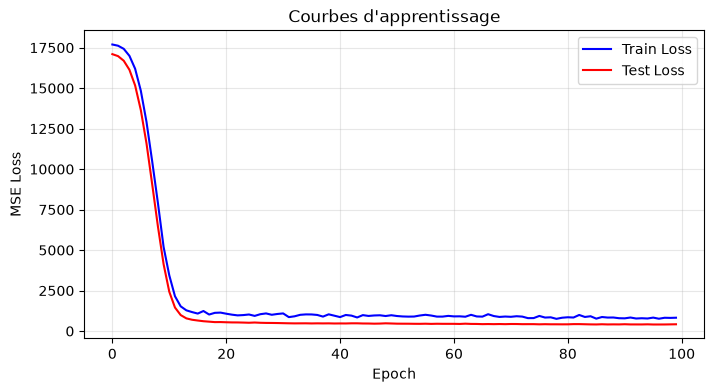

In [5]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Dataset
X, y = make_regression(n_samples=1000, n_features=10, noise=20, random_state=42)

# Preprocessing
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir en tenseurs
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

# DataLoader
dataset = TensorDataset(X_train_t, y_train_t)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

# Modèle, loss, optimiseur
model = MLP(input_size=10, hidden_sizes=[64, 32], output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Boucle d'entraînement
n_epochs = 100
train_losses = []
test_losses  = []

for epoch in range(n_epochs):
    # TRAIN
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()          # 1. Reset gradients
        output = model(X_batch)        # 2. Forward pass
        loss = criterion(output, y_batch)  # 3. Loss
        loss.backward()                # 4. Backward pass
        optimizer.step()               # 5. Update weights
        epoch_loss += loss.item()
    
    # EVAL
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t)
        test_loss = criterion(test_pred, y_test_t).item()
    
    train_losses.append(epoch_loss / len(loader))
    test_losses.append(test_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}] "
              f"Train Loss: {train_losses[-1]:.2f} | "
              f"Test Loss: {test_loss:.2f}")

# Visualisation
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="red")
plt.title("Courbes d'apprentissage")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

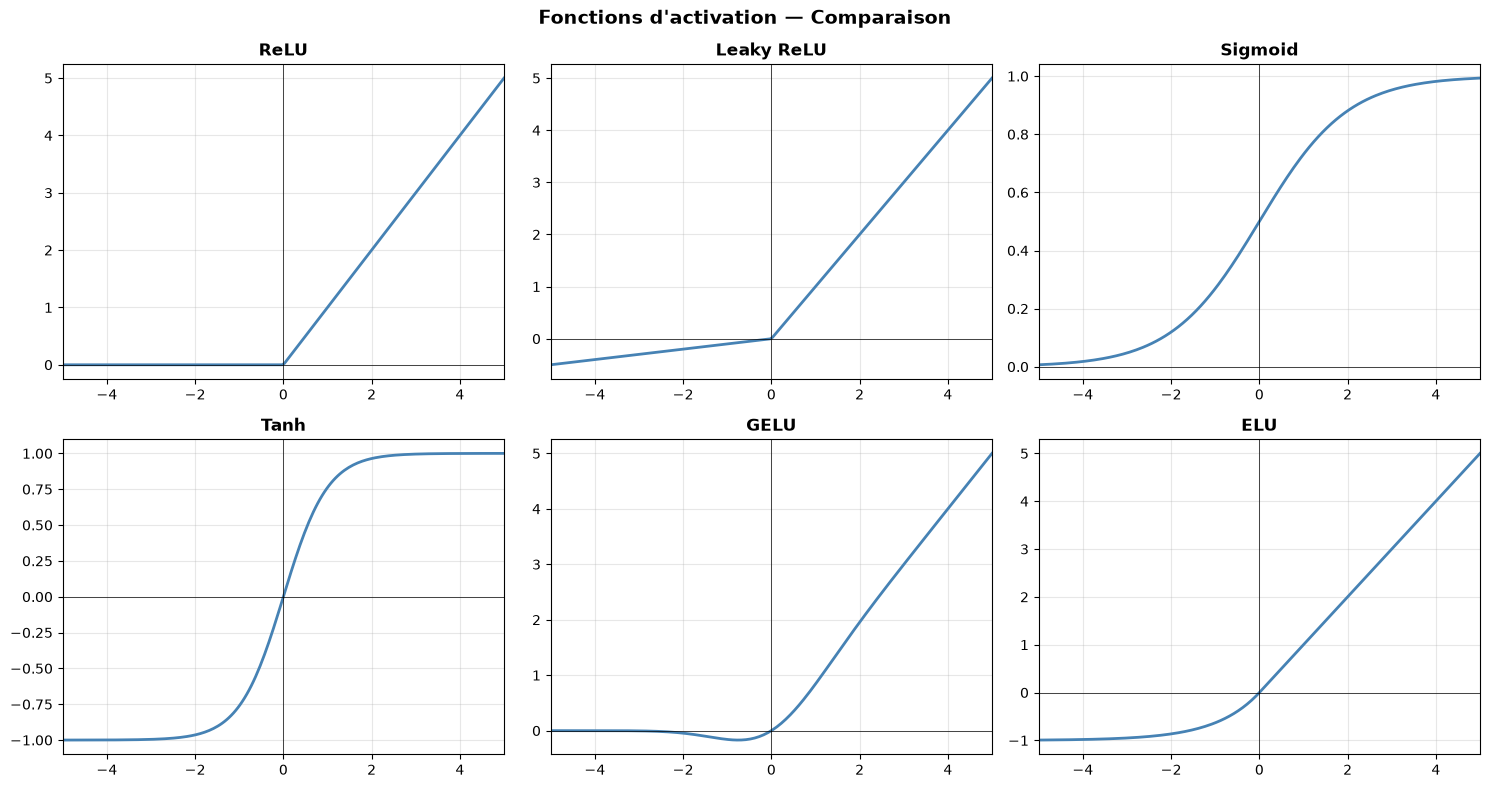

=== QUAND UTILISER QUOI ? ===

ReLU        → couches cachées en général (défaut)
              Simple, rapide, évite le vanishing gradient
              Problème : dead neurons (sortie toujours 0)

Leaky ReLU  → si tu as des dead neurons avec ReLU
              f(x) = x si x>0, 0.1x si x≤0

Sigmoid     → couche de SORTIE pour classification binaire
              Sortie ∈ [0,1] → interprétable comme probabilité
              Problème : vanishing gradient sur les couches cachées

Tanh        → RNNs et LSTMs
              Sortie ∈ [-1,1], centrée sur 0

GELU        → Transformers (BERT, GPT)
              Lisse, performant sur le NLP

ELU         → alternative à ReLU, pas de dead neurons
              Légèrement plus lent à calculer

=== PROBLÈME DU VANISHING GRADIENT ===

Avec Sigmoid dans les couches cachées :
  gradient × 0.25 × 0.25 × 0.25 = gradient × 0.016
  Après 10 couches → gradient ≈ 0 → les premières couches n'apprennent plus !

Avec ReLU :
  gradient × 1 × 1 × 1 = gradient inc

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# FONCTIONS D'ACTIVATION — comparaison visuelle
x = torch.linspace(-5, 5, 200)

activations = {
    "ReLU":         nn.ReLU(),
    "Leaky ReLU":   nn.LeakyReLU(0.1),
    "Sigmoid":      nn.Sigmoid(),
    "Tanh":         nn.Tanh(),
    "GELU":         nn.GELU(),
    "ELU":          nn.ELU(),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (nom, activation) in zip(axes.flat, activations.items()):
    with torch.no_grad():
        y = activation(x)
    
    ax.plot(x.numpy(), y.numpy(), color="steelblue", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(nom, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

plt.suptitle("Fonctions d'activation — Comparaison", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("=== QUAND UTILISER QUOI ? ===")
print("""
ReLU        → couches cachées en général (défaut)
              Simple, rapide, évite le vanishing gradient
              Problème : dead neurons (sortie toujours 0)

Leaky ReLU  → si tu as des dead neurons avec ReLU
              f(x) = x si x>0, 0.1x si x≤0

Sigmoid     → couche de SORTIE pour classification binaire
              Sortie ∈ [0,1] → interprétable comme probabilité
              Problème : vanishing gradient sur les couches cachées

Tanh        → RNNs et LSTMs
              Sortie ∈ [-1,1], centrée sur 0

GELU        → Transformers (BERT, GPT)
              Lisse, performant sur le NLP

ELU         → alternative à ReLU, pas de dead neurons
              Légèrement plus lent à calculer
""")

# Impact sur l'entraînement
print("=== PROBLÈME DU VANISHING GRADIENT ===")
print("""
Avec Sigmoid dans les couches cachées :
  gradient × 0.25 × 0.25 × 0.25 = gradient × 0.016
  Après 10 couches → gradient ≈ 0 → les premières couches n'apprennent plus !

Avec ReLU :
  gradient × 1 × 1 × 1 = gradient inchangé
  Les gradients circulent librement → entraînement plus stable
""")

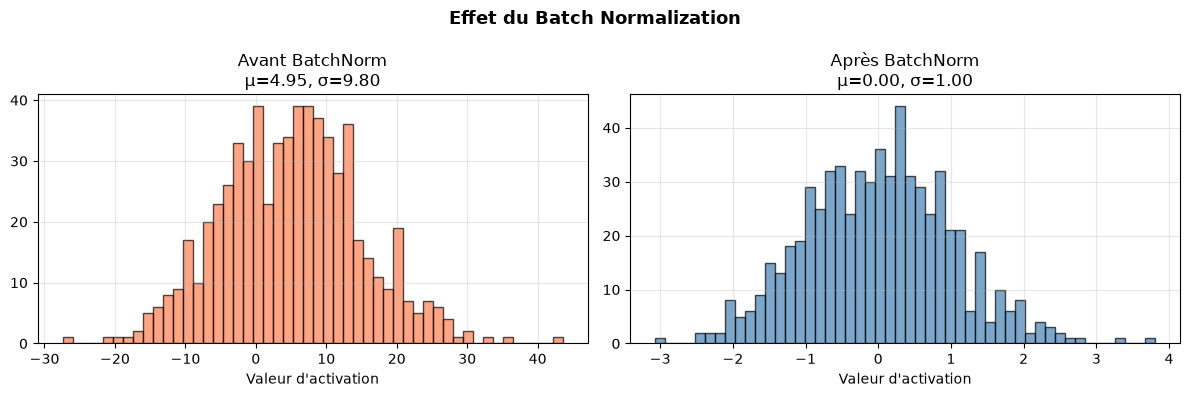

Entraînement sans BatchNorm...
Entraînement avec BatchNorm...


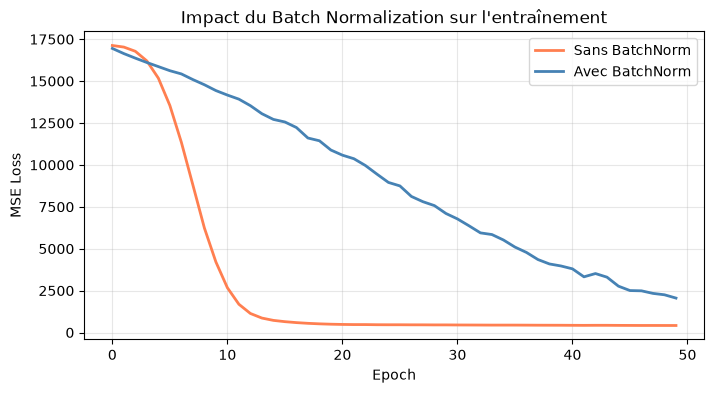


Loss finale sans BN : 418.05
Loss finale avec BN : 2053.24


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# BATCH NORMALIZATION
# Normalise les activations de chaque couche pendant l'entraînement
# → stabilise et accélère l'entraînement
# → agit comme une régularisation légère

# Démonstration visuelle
np.random.seed(42)
batch_size = 64
n_features = 10

# Simuler des activations avant BatchNorm
activations_before = np.random.randn(batch_size, n_features) * 10 + 5

# BatchNorm en PyTorch
bn = nn.BatchNorm1d(n_features)
activations_tensor = torch.FloatTensor(activations_before)
activations_after = bn(activations_tensor).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(activations_before.flatten(), bins=50, 
             color="coral", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Avant BatchNorm\nμ={activations_before.mean():.2f}, σ={activations_before.std():.2f}")
axes[0].set_xlabel("Valeur d'activation")
axes[0].grid(True, alpha=0.3)

axes[1].hist(activations_after.flatten(), bins=50,
             color="steelblue", edgecolor="black", alpha=0.7)
axes[1].set_title(f"Après BatchNorm\nμ={activations_after.mean():.2f}, σ={activations_after.std():.2f}")
axes[1].set_xlabel("Valeur d'activation")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Effet du Batch Normalization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Comparer réseau avec et sans BatchNorm
class MLPsansBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

class MLPavecBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X, y = make_regression(n_samples=1000, n_features=10, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = torch.FloatTensor(scaler.fit_transform(X_train))
X_test = torch.FloatTensor(scaler.transform(X_test))
y_train = torch.FloatTensor(y_train).unsqueeze(1)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

def train_model(model, n_epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(n_epochs):
        model.train()
        for X_b, y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            losses.append(criterion(model(X_test), y_test).item())
    return losses

print("Entraînement sans BatchNorm...")
losses_sans = train_model(MLPsansBN())
print("Entraînement avec BatchNorm...")
losses_avec = train_model(MLPavecBN())

plt.figure(figsize=(8, 4))
plt.plot(losses_sans, label="Sans BatchNorm", color="coral", linewidth=2)
plt.plot(losses_avec, label="Avec BatchNorm", color="steelblue", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Impact du Batch Normalization sur l'entraînement")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"\nLoss finale sans BN : {losses_sans[-1]:.2f}")
print(f"Loss finale avec BN : {losses_avec[-1]:.2f}")